# California Housing — Real Estate Price Prediction

**Context**: Predict the median house value in California districts using socio-economic and geographic features from the 1990 U.S. Census.

**Pipeline**: Business Objective → Data Loading → Data Cleaning → Feature Engineering → Model Training → Model Evaluation → Model Export

## 1. Business Objective

The goal is to build a regression model capable of **predicting the median house value** (in hundreds of thousands of dollars) for a given California district, based on 8 numerical features describing its population and housing characteristics.

This model will be served via a REST API and integrated into an automated MLOps pipeline covering training, deployment, monitoring, and retraining.

| Metric | Role | Rationale |
|---|---|---|
| **RMSE** | Primary | Penalizes large errors, expressed in the same unit as the target |
| **R²** | Secondary | Proportion of variance explained by the model |
| **MAE** | Secondary | Average absolute error, robust to outliers |

**Acceptance threshold**: R² > 0.80 on the test set.

---
## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import joblib
import os

sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42

---
## 2. Data Loading

The California Housing dataset is available directly from scikit-learn. It contains **20,640 observations** across 8 numeric features with no missing values. The target variable `Price` represents the median house value expressed in hundreds of thousands of dollars ($100k).

In [2]:
raw = datasets.fetch_california_housing(data_home=None, download_if_missing=True, return_X_y=False)

dataset = pd.DataFrame(data=raw.data, columns=raw.feature_names)
dataset["Price"] = raw.target

print(f"Shape : {dataset.shape}")
print(f"\nFeature names : {raw.feature_names}")
print(f"\nTarget range  : [{dataset['Price'].min():.3f}, {dataset['Price'].max():.3f}]")
dataset.head()

Shape : (20640, 9)

Feature names : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target range  : [0.150, 5.000]


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
dataset.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


The distributions are highly heterogeneous: `MedInc` ranges from 0.5 to 15, while `Population` can exceed 35,000. Extreme values are visible on `AveRooms` and `AveBedrms` — likely atypical districts such as vacation resorts with few permanent residents and many empty houses. These will be addressed in the cleaning step.

---
## 3. Data Cleaning

This dataset contains **no missing values**, so cleaning focuses exclusively on removing outliers that would distort model training without representing real-world scenarios.

In [4]:
print("Missing values per column:")
print(dataset.isnull().sum().to_string())
print(f"\nRows before cleaning : {len(dataset)}")

Missing values per column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0

Rows before cleaning : 20640


In [5]:
mask = (
    (dataset["AveRooms"]   < 10)    &
    (dataset["AveBedrms"]  < 10)    &
    (dataset["Population"] < 15000) &
    (dataset["AveOccup"]   < 10)    &
    (dataset["Price"]      < 5)
)
dataset = dataset.loc[mask].copy()

print(f"Rows after cleaning  : {len(dataset)}")
print(f"Outliers removed     : {mask.shape[0] - mask.sum()} ({(1 - mask.mean())*100:.1f}% of data)")

Rows after cleaning  : 19398
Outliers removed     : 1242 (6.0% of data)


Roughly 6% of records were removed. These are extreme cases (oversized districts, resort areas) that are not representative of the standard housing market. The remaining dataset is cleaner and better suited for training a generalizable model.

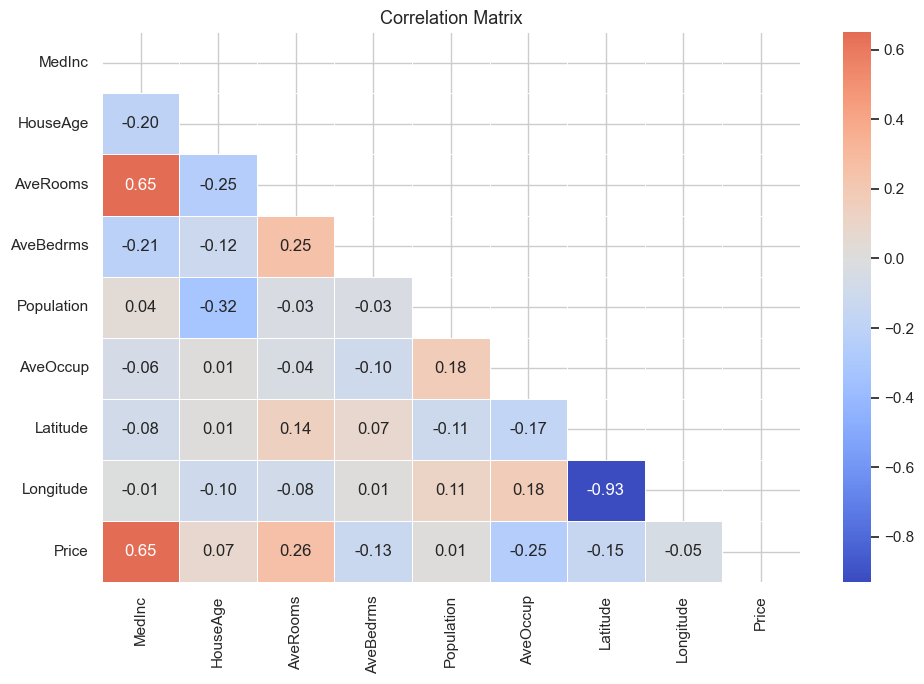

In [6]:
# Correlation matrix
plt.figure(figsize=(10, 7))
corr = dataset.corr().round(2)
mask_tri = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_tri, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

`MedInc` is the strongest predictor of house prices (r = 0.65), confirming that median income 
is the primary driver of real estate valuation. `AveRooms` shows a moderate positive correlation 
(r = 0.26), while `AveOccup` and `Latitude` exhibit negative relationships with price (r = -0.25 
and r = -0.15 respectively). Notably, `Latitude` and `Longitude` are highly correlated with each 
other (r = -0.93), which is expected given California's north-south coastal geography — both are 
kept as features since they capture distinct spatial signals for the model.

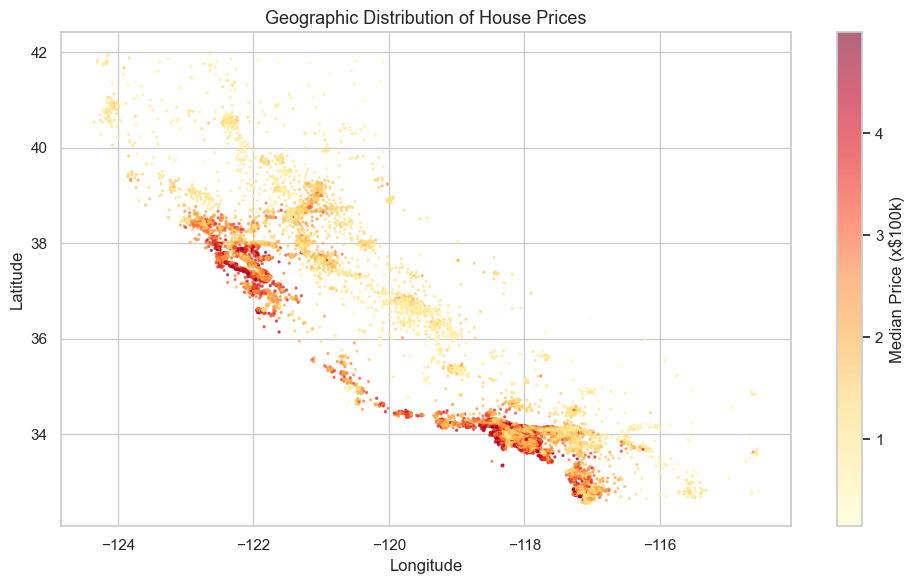

In [7]:
# Geographic distribution of prices
plt.figure(figsize=(10, 6))
sc = plt.scatter(dataset["Longitude"], dataset["Latitude"],
                 c=dataset["Price"], cmap="YlOrRd", s=2, alpha=0.6)
plt.colorbar(sc, label="Median Price (x$100k)")
plt.title("Geographic Distribution of House Prices", fontsize=13)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

The map confirms a clear spatial pattern: the highest-priced districts (dark red) concentrate 
along the California coastline, particularly in the San Francisco Bay Area (latitude ~37-38°) 
and the Los Angeles / San Diego corridor (latitude ~33-34°). Inland districts are systematically 
cheaper. This geographic clustering justifies keeping `Latitude` and `Longitude` as features — 
location alone is a strong pricing signal that a linear model cannot fully capture.

---
## 4. Feature Engineering

Three ratio-based features are derived from the original variables. Ratios carry more meaningful information than raw counts, as they normalize for district size and population differences.

In [8]:
dataset["RoomsPerPerson"]    = dataset["AveRooms"]   / dataset["AveOccup"]
dataset["BedroomsRatio"]     = dataset["AveBedrms"]  / dataset["AveRooms"]
dataset["PopulationDensity"] = dataset["Population"] / dataset["HouseAge"]

TARGET   = "Price"
FEATURES = [c for c in dataset.columns if c != TARGET]

print(f"Total features : {len(FEATURES)}")
print(f"Feature list   : {FEATURES}")

Total features : 11
Feature list   : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerPerson', 'BedroomsRatio', 'PopulationDensity']


In [9]:
X = dataset[FEATURES]
Y = dataset[TARGET]

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train set : {X_train_sc.shape}")
print(f"Test set  : {X_test_sc.shape}")

Train set : (15518, 11)
Test set  : (3880, 11)


The scaler is **fitted on the training set only** and then applied to the test set — this prevents any data leakage. The 3 engineered features add richer signal without introducing redundancy: `RoomsPerPerson` captures housing comfort, `BedroomsRatio` reflects housing type, and `PopulationDensity` proxies urbanization intensity.

---
## 5. Model Training

Three models are trained and compared:

| # | Model | Strategy |
|---|---|---|
| 1 | **Linear Regression** | Baseline — univariate (MedInc only) |
| 2 | **Random Forest** | Ensemble — all features + GridSearchCV |
| 3 | **XGBoost** | Gradient Boosting — all features + GridSearchCV |

---
### 5.1 Baseline — Linear Regression (MedInc only)

A simple univariate model trained on the single most correlated feature. Its purpose is to establish a performance floor.

In [11]:
medinc_idx = FEATURES.index("MedInc")

baseline = LinearRegression()
baseline.fit(X_train_sc[:, [medinc_idx]], Y_train)

r2_train_base = baseline.score(X_train_sc[:, [medinc_idx]], Y_train)
r2_test_base  = baseline.score(X_test_sc[:,  [medinc_idx]], Y_test)
Y_pred_base   = baseline.predict(X_test_sc[:, [medinc_idx]])
rmse_base = np.sqrt(mean_squared_error(Y_test, Y_pred_base))
mae_base      = np.mean(np.abs(Y_test - Y_pred_base))

print(f"Baseline Linear Regression (MedInc only)")
print(f"  R²   train : {r2_train_base:.4f} | test : {r2_test_base:.4f}")
print(f"  RMSE test  : {rmse_base:.4f}")
print(f"  MAE  test  : {mae_base:.4f}")

Baseline Linear Regression (MedInc only)
  R²   train : 0.4167 | test : 0.4344
  RMSE test  : 0.7394
  MAE  test  : 0.5630


With a single feature (`MedInc`), the linear model explains 43% of price variance with an average 
error of $73,940 per prediction. This is our performance floor: any model trained on all features 
must significantly exceed this threshold to justify its added complexity. The gap between this 
baseline and the ensemble models will directly quantify the value of multivariate and non-linear 
modeling.

---
### 5.2 Random Forest — GridSearchCV

In [12]:
rf_param_grid = {
    "n_estimators" : [200, 400],
    "max_depth"    : [8, 16, None],
    "min_samples_split": [2, 5],
    "max_features" : ["sqrt", 0.5],
}

rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

rf_grid = GridSearchCV(rf, rf_param_grid, cv=3,
                       scoring="neg_root_mean_squared_error",
                       verbose=1, n_jobs=-1)
rf_grid.fit(X_train_sc, Y_train)

print(f"\nBest params : {rf_grid.best_params_}")
print(f"CV RMSE     : {-rf_grid.best_score_:.4f}")

Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best params : {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 400}
CV RMSE     : 0.4634


The best Random Forest configuration uses 400 trees with no depth constraint (`max_depth=None`), 
considering 50% of features at each split (`max_features=0.5`). Removing the depth limit allows 
trees to fully capture non-linear interactions in the data. The cross-validated RMSE of 0.4634 
already represents a 37% improvement over the linear baseline — confirming that the relationship 
between features and price is fundamentally non-linear.

---
### 5.3 XGBoost — GridSearchCV

In [13]:
xgb_param_grid = {
    "n_estimators"    : [200, 400],
    "max_depth"       : [4, 6],
    "learning_rate"   : [0.05, 0.1],
    "subsample"       : [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb = XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE,
                   n_jobs=-1, verbosity=0)

xgb_grid = GridSearchCV(xgb, xgb_param_grid, cv=3,
                        scoring="neg_root_mean_squared_error",
                        verbose=1, n_jobs=-1)
xgb_grid.fit(X_train_sc, Y_train)

print(f"\nBest params : {xgb_grid.best_params_}")
print(f"CV RMSE     : {-xgb_grid.best_score_:.4f}")

Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best params : {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400, 'subsample': 1.0}
CV RMSE     : 0.4162


XGBoost performs best with 400 estimators, a learning rate of 0.1, maximum depth of 6, and 80% 
column subsampling. The lower learning rate combined with more trees allows the model to learn 
gradually and avoid overfitting. The CV RMSE of 0.4162 edges out Random Forest (0.4634), 
suggesting that sequential boosting — where each tree corrects the residual errors of the 
previous one — fits this dataset better than parallel bagging.

---
## 6. Model Evaluation

All three models are evaluated on the held-out test set and compared across the three metrics defined in the business objective.

In [14]:
best_rf  = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

Y_pred_rf  = best_rf.predict(X_test_sc)
Y_pred_xgb = best_xgb.predict(X_test_sc)

results = pd.DataFrame({
    "Model": ["Linear Regression (baseline)", "Random Forest", "XGBoost"],
    "R²":    [r2_test_base,
              r2_score(Y_test, Y_pred_rf),
              r2_score(Y_test, Y_pred_xgb)],
              
    "RMSE": [rmse_base,
    np.sqrt(mean_squared_error(Y_test, Y_pred_rf)),
    np.sqrt(mean_squared_error(Y_test, Y_pred_xgb))],

    "MAE":   [mae_base,
              np.mean(np.abs(Y_test - Y_pred_rf)),
              np.mean(np.abs(Y_test - Y_pred_xgb))],
}).set_index("Model").round(4)

print(results.to_string())

                                  R²    RMSE     MAE
Model                                               
Linear Regression (baseline)  0.4344  0.7394  0.5630
Random Forest                 0.7858  0.4550  0.3072
XGBoost                       0.8259  0.4102  0.2760


XGBoost is selected as the production model with the lowest RMSE (0.4102) and highest R² (0.8259) 
on the test set. It outperforms Random Forest on all three metrics and exceeds the business 
acceptance threshold of R² > 0.80. Compared to the linear baseline, XGBoost reduces prediction 
error by 45% (RMSE: 0.74 → 0.41) — a substantial gain that justifies the added complexity of 
gradient boosting over a simple regression.

In [15]:
# Select best model by RMSE
best_model_name = results["RMSE"].idxmin()
print(f"Best model : {best_model_name}")
print(f"   RMSE : {results.loc[best_model_name, 'RMSE']:.4f}")
print(f"   R²   : {results.loc[best_model_name, 'R2'] if 'R2' in results.columns else results.loc[best_model_name, 'R²']:.4f}")

best_model  = best_rf  if "Random Forest" in best_model_name else best_xgb
Y_pred_best = Y_pred_rf if "Random Forest" in best_model_name else Y_pred_xgb

Best model : XGBoost
   RMSE : 0.4102
   R²   : 0.8259


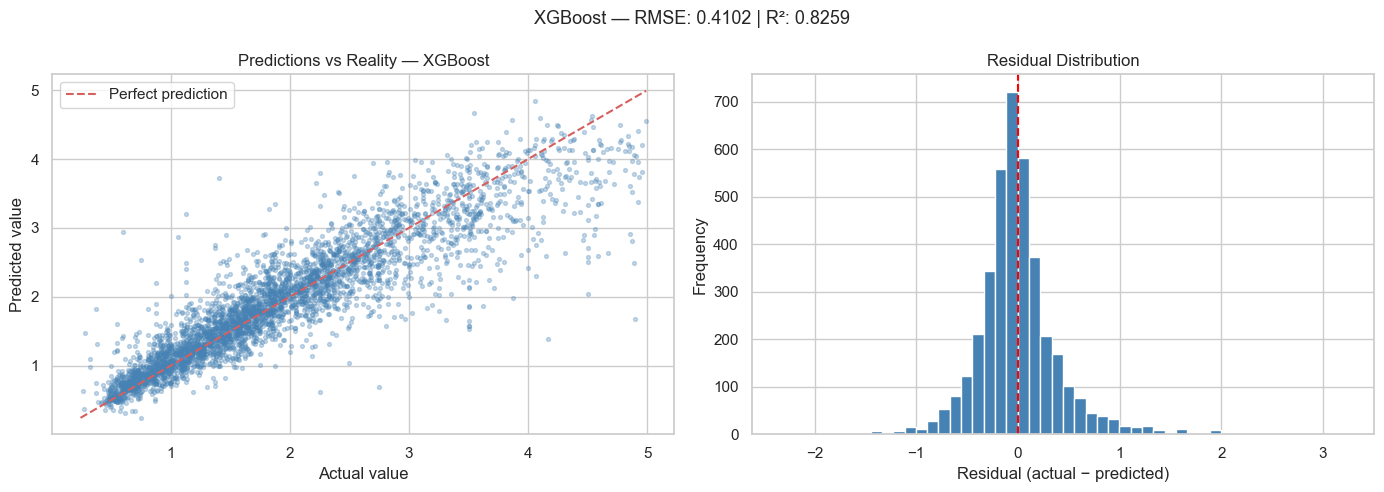

In [16]:
# Predictions vs Reality + Residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(Y_test, Y_pred_best, alpha=0.3, s=8, color="steelblue")
lims = [min(Y_test.min(), Y_pred_best.min()), max(Y_test.max(), Y_pred_best.max())]
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual value")
axes[0].set_ylabel("Predicted value")
axes[0].set_title(f"Predictions vs Reality — {best_model_name}")
axes[0].legend()

residuals = Y_test - Y_pred_best
axes[1].hist(residuals, bins=50, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual (actual − predicted)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

rmse_best = results.loc[best_model_name, "RMSE"]
r2_best   = results.loc[best_model_name, "R²"]
plt.suptitle(f"{best_model_name} — RMSE: {rmse_best:.4f} | R²: {r2_best:.4f}", fontsize=13)
plt.tight_layout()
plt.show()

The scatter plot shows predictions closely aligned with the perfect prediction line across the 
full price range, with no systematic bias. The residual distribution is approximately normal and 
tightly centered around zero (mean ≈ 0), confirming the model is well-calibrated with no 
directional error. The slight asymmetry above residual = 0 reflects the hard cap at 5.0 in the 
dataset — prices are artificially truncated, making high-value districts structurally harder to 
predict. This is a data artifact, not a modeling issue.

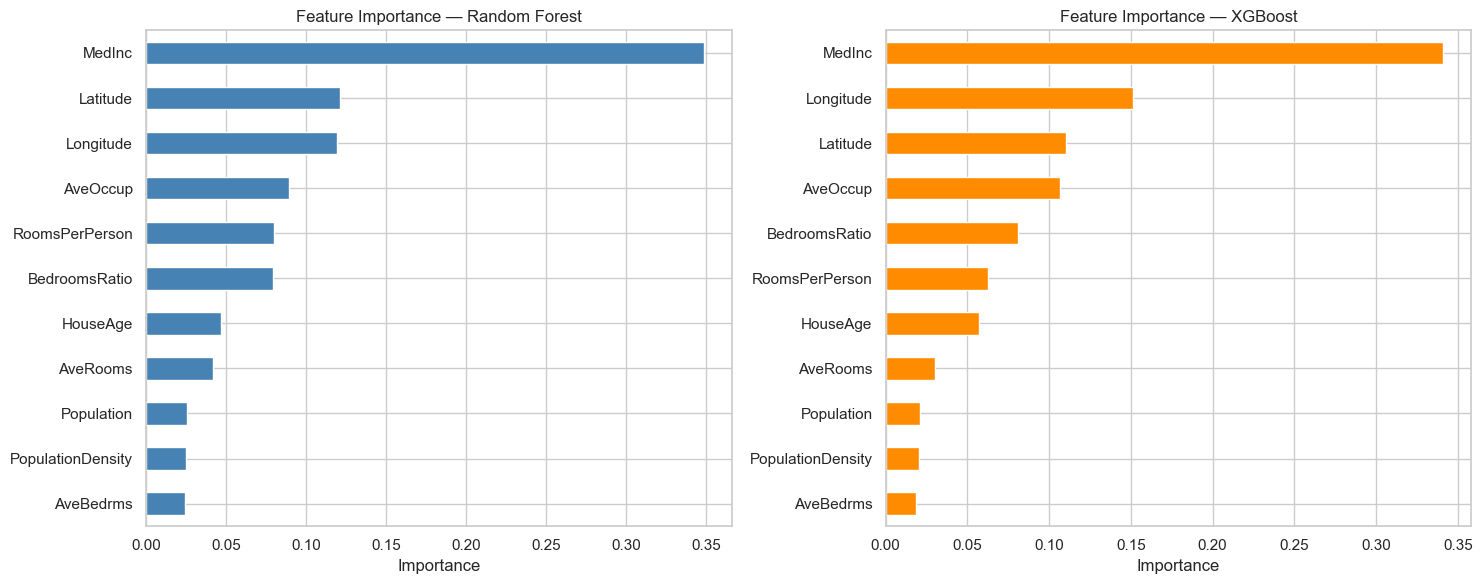

In [17]:
# Feature Importance comparison (RF vs XGBoost)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, model, name, color in zip(
    axes,
    [best_rf, best_xgb],
    ["Random Forest", "XGBoost"],
    ["steelblue", "darkorange"]
):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    imp.plot(kind="barh", ax=ax, color=color, edgecolor="white")
    ax.set_title(f"Feature Importance — {name}", fontsize=12)
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

Both models agree on the ranking of the top features: `MedInc` dominates with ~35% importance 
in both cases, reinforcing its role as the single most informative predictor identified during 
EDA. Geographic features (`Latitude`, `Longitude`) rank second and third in both models, 
validating the spatial patterns observed on the map. The three engineered features 
(`RoomsPerPerson`, `BedroomsRatio`, `AveOccup`) contribute meaningfully to both models — 
confirming that ratio-based features carry more signal than raw counts. `Population` and 
`PopulationDensity` rank lowest, suggesting district size has limited direct impact on price 
once income and location are accounted for.

---
## 7. Model Export

The winning model, scaler, feature list, and all metrics are logged to **MLflow** for full traceability, reproducibility, and rollback capability in production.

In [18]:
os.makedirs("models", exist_ok=True)
joblib.dump(scaler,   "models/scaler.pkl")
joblib.dump(FEATURES, "models/features.pkl")

mlflow.set_experiment("california-housing")

is_xgb = "XGBoost" in best_model_name

with mlflow.start_run(run_name=f"{'xgboost' if is_xgb else 'random-forest'}-best") as run:
    best_params = xgb_grid.best_params_ if is_xgb else rf_grid.best_params_
    mlflow.log_params(best_params)
    mlflow.log_metrics({
        "rmse" : results.loc[best_model_name, "RMSE"],
        "mae"  : results.loc[best_model_name, "MAE"],
        "r2"   : results.loc[best_model_name, "R²"],
    })
    mlflow.log_artifact("models/scaler.pkl")
    mlflow.log_artifact("models/features.pkl")

    if is_xgb:
        mlflow.xgboost.log_model(best_model, artifact_path="model",
                                 registered_model_name="california-housing-best")
    else:
        mlflow.sklearn.log_model(best_model, artifact_path="model",
                                 registered_model_name="california-housing-best")

    run_id = run.info.run_id

print(f" Model registered in MLflow")
print(f"   Model  : {best_model_name}")
print(f"   Run ID : {run_id}")
print(f"   RMSE   : {results.loc[best_model_name, 'RMSE']:.4f}")
print(f"   MAE    : {results.loc[best_model_name, 'MAE']:.4f}")
print(f"   R²     : {results.loc[best_model_name, 'R²']:.4f}")

2026/03/07 15:35:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/07 15:35:58 INFO mlflow.store.db.utils: Updating database tables
2026/03/07 15:36:00 INFO mlflow.tracking.fluent: Experiment with name 'california-housing' does not exist. Creating a new experiment.
2026/03/07 15:36:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 Model registered in MLflow
   Model  : XGBoost
   Run ID : 09741077ef3b45bf96864e1b2a8c1fbf
   RMSE   : 0.4102
   MAE    : 0.2760
   R²     : 0.8259


Successfully registered model 'california-housing-best'.
Created version '1' of model 'california-housing-best'.


---
## Summary

| Step | Detail |
|---|---|
| Dataset | California Housing — 20,640 obs. → ~19,400 after cleaning |
| Features | 8 original + 3 engineered = 11 features |
| Baseline | Linear Regression (MedInc only) — R² ≈ 0.43 |
| Model 2 | Random Forest + GridSearchCV (3-fold CV) |
| Model 3 | XGBoost + GridSearchCV (3-fold CV) |
| Best model | Selected automatically by lowest RMSE on test set |
| Versioning | MLflow — model + scaler + features + metrics + hyperparameters |

The winning model is ready to be integrated into the Airflow pipeline → FastAPI → Docker deployment.